
# Probing what drives TETHER's predictions

The goal here is to see *how* the two stacked models turn their inputs into a score, by
holding a fixed set of real TF-TG edges and changing one input at a time.

**What each model sees**

| Model | Inputs | Output |
|---|---|---|
| `TFPeakBindingModel` (TF-DNA, frozen) | TF 3Di protein embedding, peak one-hot DNA `[L, 4]` | one binding logit per (TF, peak) |
| `TFTGRegulationModel` (TF-TG) | per-peak: binding prob, accessibility, `dist_scaled`, `dist_weight`; per-cell: TF expr, TG expr | one logit per (TF, TG) edge |

Inside `TFTGRegulationModel.forward` the peak features are built as

```
binding_score   = sigmoid(frozen_tf_dna_model(tf, peak_seq))       # [E, P]  masked by peak_mask
distance_scaled = clamp(|TSS_dist| / 250_000, 0, 1)                # [E, P]
distance_weight = exp(-|TSS_dist| / 50_000)                        # [E, P]
peak_features   = stack([binding, accessibility, dist_scaled, dist_weight])   # [E, C, P, 4]
```

1. A TG query built from `tf_expr + tg_expr` attends over the P peak tokens.
2. The classifier emits one logit per (edge, cell)
3. Those are pooled over the C sampled cells with
log-sum-exp into one edge logit.

**Two consequences worth keeping in mind while reading the sweeps below:**

1. The TF-DNA model *only* sees the TF embedding and the peak DNA sequence. Changing
   accessibility, distance, or expression cannot change a binding score — those sweeps
   move the TF-TG head only.
2. `peak_mask` is the switch that controls how many peaks an edge has. Masked peaks get
   binding, distance, and accessibility zeroed *and* are excluded from the attention
   (`key_padding_mask`), so flipping the mask is the faithful way to ask "what if this TG
   had fewer nearby peaks?".

**Run this on a GPU node** (`sbatch jupyter_dense_a100.sh`, kernel `my_env`).


## Setup


In [42]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import config
import utils
import stat_utils
import plotting_utils
import models.tf_to_tg as tf_to_tg_module

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# config.py's module-level switch decides the dataset. Override here if you want a
# different sample without editing config.py.
CELL_TYPE = "mESC"
SAMPLE_NAME = "E7.5_rep1"
SPECIES = "mouse"

print(f"{SPECIES} / {CELL_TYPE} / {SAMPLE_NAME} on {device}")
print("cache dir:", config.tf_tg_input_cache_dir)

mouse / mESC / E7.5_rep1 on cuda
cache dir: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/cached_data/mESC_cache/tf_tg_training_cache/E7.5_rep1



## 1. Load the cached test edges

`utils.load_training_cache_dataset` gives back a `DataLoader` over the cached test split
plus the TF embedding lookup tables. Nothing is rebuilt from the raw multiome data — these
are the exact edges the model was evaluated on.

Each collated batch is a dict of:

| key | shape | meaning |
|---|---|---|
| `label` | `[E]` | 1 = ground-truth edge |
| `tf_embedding` | `[E, T, 128]` | TF 3Di embedding, padded to the longest protein |
| `tf_mask` | `[E, T]` | True = amino acid sequence, False = padding |
| `peak_sequences` | `[E, P, L, 4]` | one-hot DNA for each candidate peak |
| `peak_distance` | `[E, P]` | signed peak-to-TSS distance (bp) |
| `peak_mask` | `[E, P]` | True = real peak, False = padding |
| `peak_accessibility` | `[E, C, P]` | ATAC signal per sampled cell |
| `tf_expression` / `tg_expression` | `[E, C]` | TF/TG RNA expression per sampled cell |
| `cell_mask` | `[E, C]` | True = real cell |

Peaks are stored **sorted by increasing `|TSS_dist|`**, so column `p` is the p-th closest
peak to the TG. That ordering is used to select the k nearest peaks to a TG TSS.

In [43]:
# Enough edges to find a decent number of positives; the cache is TF-major, so a
# small subset can be all one TF. Raise SCAN_EDGES if you want more variety.
SCAN_EDGES = 4096
BATCH_SIZE = 64

loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
    sample_name=SAMPLE_NAME,
    cell_type_cache_dir=config.training_cache_dir,
    split_type="test",
    subset_size=SCAN_EDGES,
    batch_size=BATCH_SIZE,
)

print("max_peaks_real   :", metadata["max_peaks_real"])
print("max_cells_per_pair:", metadata["max_cells_per_pair"])
print("n test edges     :", manifest["n_test_rows"])
print("tf_embeddings    :", tuple(tf_embeddings_tensor.shape))
print()
example = next(iter(loader))
for key, value in example.items():
    if torch.is_tensor(value):
        print(f"{key:20s} {str(tuple(value.shape)):20s} {value.dtype}")

max_peaks_real   : 90
max_cells_per_pair: 24
n test edges     : 143375
tf_embeddings    : (443, 5588, 128)

label                (64,)                torch.float32
tf_idx               (64,)                torch.int64
tg_idx               (64,)                torch.int64
peak_indices         (64, 90)             torch.int64
peak_sequences       (64, 90, 256, 4)     torch.float32
peak_distance        (64, 90)             torch.float32
peak_mask            (64, 90)             torch.bool
peak_accessibility   (64, 24, 90)         torch.float32
tf_expression        (64, 24)             torch.float32
tg_expression        (64, 24)             torch.float32
tf_embedding         (64, 5588, 128)      torch.float32
tf_mask              (64, 5588)           torch.bool
cell_mask            (64, 24)             torch.bool


In [44]:
print(tf_embeddings_tensor.shape, tf_mask_tensor.shape)

torch.Size([443, 5588, 128]) torch.Size([443, 5588])


In [45]:
from Bio import SeqIO

selected_tf = 3

tf_info = {}

tf_to_id = metadata["tf_name_to_idx"]
id_to_tf = {v: k for k, v in tf_to_id.items()}

tf_name = id_to_tf[selected_tf]
print(f"Selected TF name: {id_to_tf[selected_tf]}")
tf_info[tf_name] = {}

# Get the selected TF's amino acid sequence
tf_seq_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/tf_data/mm10/tf_sequences")
first_tf_aa_file = tf_seq_dir / f"{id_to_tf[selected_tf].capitalize()}_protein.fasta"

for record in SeqIO.parse(first_tf_aa_file, "fasta"):
    print(f"  ID: {record.id}")
    print(f"  Sequence: {record.seq}")
    print(f"  Length: {len(record)}")
    
    tf_info[tf_name]["tf_fasta_record_id"] = record.id
    tf_info[tf_name]["tf_aa_sequence"] = str(record.seq)
    tf_info[tf_name]["tf_protein_id"] = record.id

# Get the selected TF's 3Di sequence
tf_3di_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/tf_data/mm10/tf_3di_output")
tf_protein_3di_file = tf_3di_dir / "tf_proteins_3di.fasta"

for record in SeqIO.parse(tf_protein_3di_file, "fasta"):
    if record.id != tf_info[tf_name]["tf_protein_id"]:
        continue
    else:
        print(f"  3Di Sequence: {record.seq}")  # Prints the actual sequence

        tf_info[tf_name]["tf_3di_sequence"] = str(record.seq)
        
# Get the selected TF's embedding (without max length padding)
tf_embedding = tf_embeddings_tensor[selected_tf]

tf_mask = tf_mask_tensor[selected_tf]
selected_tf_emb_seq = tf_embedding[tf_mask].cpu().numpy()

tf_info[tf_name]["tf_embedding"] = selected_tf_emb_seq

print(f"  Embedding dimension: {selected_tf_emb_seq.shape[0]}")
print(f"  Sequence dimension: {selected_tf_emb_seq.shape[1]}")

Selected TF name: TFAP2A
  ID: NP_035677.3
  Sequence: MKMLWKLTDNIKYEDCEDRHDGTSNGTARLPQLGTVGQSPYTSAPPLSHTPNADFQPPYFPPPYQPIYPQSQDPYSHVNDPYSLNPLHAQPQPQHPGWPGQRQSQESGLLHTHRGLPHQLSGLDPRRDYRRHEDLLHGPHGLGSGLGDLPIHSLPHAIEDVPHVEDPGINIPDQTVIKKGPVSLSKSNSNAVSAIPINKDNLFGGVVNPNEVFCSVPGRLSLLSSTSKYKVTVAEVQRRLSPPECLNASLLGGVLRRAKSKNGGRSLREKLDKIGLNLPAGRRKAANVTLLTSLVEGEAVHLARDFGYVCETEFPAKAVAEFLNRQHSDPNEQVARKNMLLATKQICKEFTDLLAQDRSPLGNSRPNPILEPGIQSCLTHFNLISHGFGSPAVCAAVTALQNYLTEALKAMDKMYLSNNPNSHTDNSAKSSDKEEKHRK
  Length: 439
  3Di Sequence: DVVLVVLLVPDDDDDPDDDDPPDDPDDPDDDDPDDPPDDPPDDDDDPDDDDDPPDDDDDDDDDDDDPDDPDDDPPDDDDDPPDDDPPPDDDDDDDPDDPDDDDDPDDDPPDDPPDDDPDPPPDDPVDVVDDPVCVPDDDDDDDDDDPDDDPPDDDDDDDDDDDDDDPDDDDDDDPDDDDDDPDPDDDDPPPDDPDDDDLVPLQPDDDDQFDFLDWDQAPPDDPVDTDTDTAGLNQVVLCCDPPLVDDLVLLCVLSVHDDDPCRSVVVQVSCVVSVHHHDHPGDGHDDDDPLSSDGLSVLQVVLVVLLVCLVPPQCLLVVLLVVCVVDPDPVVLVVVLVVLVVLLVVLVVLLVVLVQAQAASSSDRDDHPDDPVSSVVSNSVCSSNSNNVSSVVNSVSVSVNSNSVSNSVSSVVVVVVVPPPDPPDPPVVPVVVVVVVVD
  Embedding dimension: 439
  Sequen

KeyError: 'tf_name'

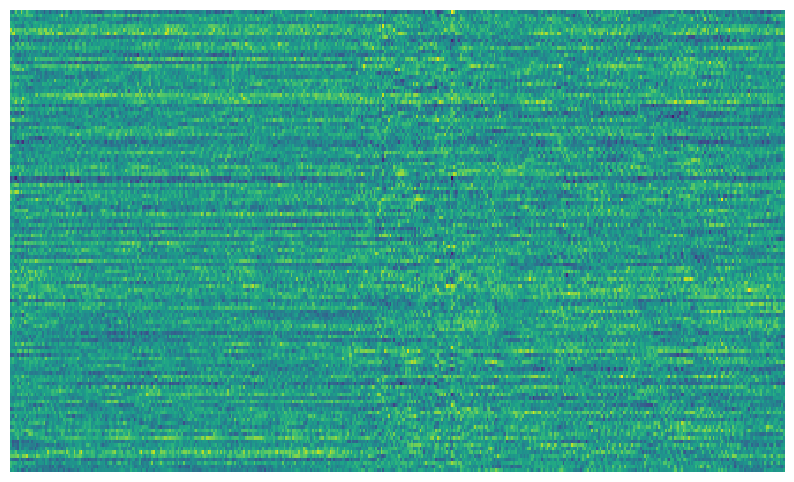

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    selected_tf_emb_seq.T,
    cmap="viridis",
    ax=ax,
    xticklabels=False,
    yticklabels=False,
    cbar=False,
)

ax.set(
    xlabel=f"TF AA position ({selected_tf_emb_seq.shape[0]})",
    ylabel=f"Embedding dimension ({selected_tf_emb_seq.shape[1]})",
    title=f"{tf_info['tf_name']} Embedding (idx: {selected_tf})",
)

ax.xaxis.set_label_position('top')

plt.show()

We will use PCA to reduce the dimensionality of each protein embedding from [128,T] $\rightarrow$ x, y, z so that similar proteins still have similar embeddings.

In [ ]:
from sklearn.decomposition import PCA

tf_emb_flat = tf_embeddings_tensor.flatten(start_dim=1)

X = tf_emb_flat.cpu().numpy()

pca = PCA(n_components=3)

coords = pca.fit_transform(X)

print(coords.shape)

x = coords[:, 0]
y = coords[:, 1]
z = coords[:, 2]

(443, 3)


Get the dot product similarity between every combination of vectors

In [ ]:
import itertools
results = []
for (idx1, v1), (idx2, v2) in itertools.combinations(enumerate(coords), 2):
    dot_product = np.dot(v1, v2)
    results.append([idx1, idx2, dot_product])
    
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

Get the JASPAR motifs for the TFs and calculate how similar they are

In [ ]:
from tqdm import tqdm

tf_name_to_motif = {}

tf_motif_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/databases/motif_information/mm10")
tf_motif_info_df = pd.read_csv(tf_motif_dir / "TF_Information_all_motifs.txt", sep="\t", header=0)
tf_motif_info_df["TF_Name"] = tf_motif_info_df["TF_Name"].str.upper()

for tf_name in tqdm(tf_to_id.keys(), desc="Loading TF motif PWMs", unit="TFs", ncols=100, total=len(tf_to_id)):
    tf_motif_id = tf_motif_info_df.loc[tf_motif_info_df["TF_Name"] == tf_name, "Motif_ID"].values[0]
    
    if pd.isna(tf_motif_id):
        continue
    
    tf_pwm_file = tf_motif_dir / "pwms_all_motifs" / f"{tf_motif_id}.txt"
    
    if not tf_pwm_file.exists():
        continue
    
    tf_pwm_data = pd.read_csv(tf_pwm_file, sep="\t", header=0, index_col=0).values
    tf_name_to_motif[tf_name] = tf_pwm_data

Loading TF motif PWMs: 100%|████████████████████████████████████| 443/443 [00:01<00:00, 438.41TFs/s]


In [ ]:
tf_info[tf_name]["tf_motif_pwm"] = tf_name_to_motif.get(tf_name, None)

In [ ]:
for tf_name, info in tf_info.items():
    print(f"TF: {tf_name}")
    print(f"  TF idx: {tf_to_id[tf_name]}")
    print(f"  Fasta Record ID: {info['tf_fasta_record_id']}")
    print(f"  Amino Acid Sequence: {info['tf_aa_sequence'][:10]}...{info['tf_aa_sequence'][-10:]}")
    print(f"  Protein ID: {info['tf_protein_id']}")
    print(f"  3Di Sequence: {info['tf_3di_sequence'][:10]}...{info['tf_3di_sequence'][-10:]}")
    print(f"  Protein sequence length: {info['tf_embedding'].shape[0]}")
    print(f"  Embedding dimension size: {info['tf_embedding'].shape[1]}")
    print(f"  Motif PWM: {info['tf_motif_pwm'] is not None}")

TF: TFAP2A
  TF idx: 3
  Fasta Record ID: NP_035677.3
  Amino Acid Sequence: MKMLWKLTDN...SSDKEEKHRK
  Protein ID: NP_035677.3
  3Di Sequence: DVVLVVLLVP...PVVVVVVVVD
  Protein sequence length: 439
  Embedding dimension size: 128
  Motif PWM: True


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


def normalize_pwm(pwm):
    """
    Normalize each position so A/C/G/T probabilities sum to 1.

    Assumes shape is:
        (motif_length, 4)
    """
    pwm = np.asarray(pwm, dtype=float)

    row_sums = pwm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0

    return pwm / row_sums


def reverse_complement_pwm(pwm):
    """
    Reverse-complement a PWM with columns ordered:
    A, C, G, T
    """
    # Reverse positions, then swap:
    # A <-> T
    # C <-> G
    return pwm[::-1, :][:, [3, 2, 1, 0]]


def pwm_similarity(
    pwm1,
    pwm2,
    min_overlap=4,
):
    """
    Find the best alignment between two PWMs.

    Returns the maximum mean cosine similarity across
    all shifts and both strands.
    """

    pwm1 = normalize_pwm(pwm1)
    pwm2 = normalize_pwm(pwm2)

    best = {
        "similarity": -np.inf,
        "shift": None,
        "strand": None,
        "overlap": None,
    }

    for strand, pwm2_test in [
        ("forward", pwm2),
        ("reverse_complement", reverse_complement_pwm(pwm2)),
    ]:

        len1 = pwm1.shape[0]
        len2 = pwm2_test.shape[0]

        # shift = position of pwm2 relative to pwm1
        for shift in range(-(len2 - min_overlap), len1 - min_overlap + 1):

            start1 = max(0, shift)
            start2 = max(0, -shift)

            overlap = min(
                len1 - start1,
                len2 - start2,
            )

            if overlap < min_overlap:
                continue

            x = pwm1[start1:start1 + overlap]
            y = pwm2_test[start2:start2 + overlap]

            # similarity for each aligned PWM position
            column_scores = [
                cosine_similarity(
                    x[i].reshape(1, -1),
                    y[i].reshape(1, -1),
                )[0, 0]
                for i in range(overlap)
            ]

            similarity = np.mean(column_scores)

            if similarity > best["similarity"]:
                best = {
                    "similarity": similarity,
                    "shift": shift,
                    "strand": strand,
                    "overlap": overlap,
                    "position_scores": np.array(column_scores),
                }

    return best

In [ ]:
import numpy as np
import plotly.graph_objects as go

result_num = 0

# First two TF coordinates
coords_to_plot = coords[results_sorted[result_num][0:2]]

tf_1_name = id_to_tf[results_sorted[result_num][0]]
tf_2_name = id_to_tf[results_sorted[result_num][1]]
print(f"TFs with highest dot product: {tf_1_name} (idx: {results_sorted[result_num][0]}), {tf_2_name} (idx: {results_sorted[result_num][1]})")

tf_names = [tf_1_name, tf_2_name]

max_val = np.abs(coords_to_plot).max() * 1.2

fig = go.Figure()

# --------------------------------------------------
# Draw x, y, z axes through the origin
# --------------------------------------------------

fig.add_trace(
    go.Scatter3d(
        x=[-max_val, max_val],
        y=[0, 0],
        z=[0, 0],
        mode="lines",
        line=dict(width=3),
        hoverinfo="skip",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[0, 0],
        y=[-max_val, max_val],
        z=[0, 0],
        mode="lines",
        line=dict(width=3),
        hoverinfo="skip",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=[0, 0],
        y=[0, 0],
        z=[-max_val, max_val],
        mode="lines",
        line=dict(width=3),
        hoverinfo="skip",
    )
)

# --------------------------------------------------
# Plot TF vectors from the origin
# --------------------------------------------------

for i, (x, y, z) in enumerate(coords_to_plot):

    # Vector line
    fig.add_trace(
        go.Scatter3d(
            x=[0, x],
            y=[0, y],
            z=[0, z],
            mode="lines",
            line=dict(width=6),
            name=f"TF {i}",
            hoverinfo="skip",
        )
    )

    # Vector endpoint
    fig.add_trace(
        go.Scatter3d(
            x=[x],
            y=[y],
            z=[z],
            mode="markers+text",
            marker=dict(size=6),
            text=[f"TF {i}"],
            textposition="top center",
            name=f"TF {i}",
            customdata=[[i, tf_names[i]]],
            hovertemplate=(
                "%{customdata[1]}<br>"
                "<extra></extra>"
            ),
        )
    )

# Origin
fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="markers+text",
        marker=dict(size=5),
        text=["Origin"],
        textposition="bottom center",
        name="Origin",
        hoverinfo="skip",
    )
)

# --------------------------------------------------
# Layout
# --------------------------------------------------

fig.update_layout(
    title="TF embeddings in PCA space",
    scene=dict(
        xaxis=dict(
            range=[-max_val, max_val],
            showgrid=False,
            showbackground=False,
            zeroline=False,
        ),
        yaxis=dict(
            range=[-max_val, max_val],
            showgrid=False,
            showbackground=False,
            zeroline=False,
        ),
        zaxis=dict(
            range=[-max_val, max_val],
            showgrid=False,
            showbackground=False,
            zeroline=False,
        ),
        aspectmode="cube",
    ),
    width=850,
    height=850,
)

fig.show()

TFs with highest dot product: ELF1 (idx: 219), CIC (idx: 387)



## 2. Load the models

`utils.load_tf_tg_regulation_model` rebuilds both models and loads both checkpoints: it
loads the TF-DNA checkpoint, freezes that model, and hands it to `TFTGRegulationModel` as
the `tf_peak_model` submodule. So the frozen TF-DNA model used for the binding sweeps is
literally the same object the TF-TG model calls internally — no risk of probing different
weights than the ones making the predictions.

In [ ]:
TF_DNA_CKPT = config.tf_dna_model_checkpoints[CELL_TYPE]
TF_TG_CKPT = utils.find_latest_checkpoint(config.CHKPT_DIR, CELL_TYPE, SAMPLE_NAME)

print("TF-DNA checkpoint:", TF_DNA_CKPT.name)
print("TF-TG  checkpoint:", TF_TG_CKPT.name)

tf_tg_lit = utils.load_tf_tg_regulation_model(
    tf_dna_model_path=TF_DNA_CKPT,
    tf_tg_model_path=TF_TG_CKPT,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    tf_peak_chunk_size=128,
    compile_model=False,   # keep off: the sweeps change shapes and compile would re-trace
    device=device,
)
tf_tg_lit = tf_tg_lit.to(device).eval()

tf_tg_model = tf_tg_lit.model                  # TFTGRegulationModel
tf_dna_model = tf_tg_model.tf_peak_model       # the frozen TFPeakBindingModel inside it

print("pooling:", tf_tg_lit.pooling_mode, "temperature:", tf_tg_lit.pooling_temperature)

INFO:root:Latest checkpoint for mESC E7.5_rep1: Job 3704585 Epoch 73


TF-DNA checkpoint: epoch=07-val_auroc=0.9743-val_loss=0.1661.ckpt
TF-TG  checkpoint: epoch=73-val_auroc=0.7601-val_loss=0.5792.ckpt
pooling: lse temperature: 1.0



## 3. Prediction helpers

Three things to make the rest of the notebook short:

* `predict_edges` — full TF-TG forward on a batch, returning edge and per-cell scores.
  It calls `LitTFTGRegulationModel.forward`, i.e. exactly the path used in training/eval.
* `tf_dna_binding` — runs the frozen TF-DNA model alone on every (TF, peak) pair in a
  batch, so you can see the binding layer that feeds the head.
* `clone_batch` / `subset_batch` / `concat_batches` — for building perturbed copies.

In [ ]:
@torch.no_grad()
def predict_edges(batch):
    """Full TF-TG forward. Returns edge probs [E], edge logits [E], cell logits [E, C]."""
    device_batch = tf_to_tg_module.move_batch_to_device(batch, device)
    edge_logits, cell_logits = tf_tg_lit(device_batch)
    return (
        torch.sigmoid(edge_logits).float().cpu(),
        edge_logits.float().cpu(),
        cell_logits.float().cpu(),
    )


@torch.no_grad()
def tf_dna_binding(batch, chunk_size=256):
    """Frozen TF-DNA model on every (TF, peak) pair. Returns binding probs [E, P].

    This is the `binding_score` tensor the TF-TG head consumes, before masking. Only the
    TF embedding and the peak DNA sequence enter here -- accessibility, distance, and
    expression are invisible to this model.
    """
    E, P = batch["peak_mask"].shape
    L = batch["peak_sequences"].shape[2]

    peak_seq_flat = batch["peak_sequences"].reshape(E * P, L, 4).float()
    tf_rows = batch["tf_idx"].repeat_interleave(P)          # [E*P] rows of the TF table

    out = torch.zeros(E * P)
    for start in range(0, E * P, chunk_size):
        sel = slice(start, min(start + chunk_size, E * P))
        rows = tf_rows[sel]

        tf_emb = tf_embeddings_tensor[rows].float()
        tf_msk = tf_mask_tensor[rows].bool()

        # Crop trailing all-padding positions -- exact, and much faster than the full 5588.
        crop = int(tf_msk.sum(dim=1).max())
        tf_emb, tf_msk = tf_emb[:, :crop], tf_msk[:, :crop]

        logits = tf_dna_model(
            tf_embedding=tf_emb.to(device),
            tf_mask=tf_msk.to(device),
            peak_embedding=peak_seq_flat[sel].to(device),
        )
        out[sel] = torch.sigmoid(logits).float().cpu()

    return out.reshape(E, P)


def clone_batch(batch):
    return {k: (v.clone() if torch.is_tensor(v) else list(v)) for k, v in batch.items()}


def subset_batch(batch, idx):
    idx = torch.as_tensor(idx, dtype=torch.long)
    out = {}
    for key, value in batch.items():
        if torch.is_tensor(value):
            out[key] = value[idx]
        else:
            out[key] = [value[i] for i in idx.tolist()]
    return out


def concat_batches(batches):
    out = {}
    for key, value in batches[0].items():
        if torch.is_tensor(value):
            out[key] = torch.cat([b[key] for b in batches], dim=0)
        else:
            out[key] = [x for b in batches for x in b[key]]
    return out


def collect_edges(loader, n_pos, n_neg, max_batches=64):
    """Pull edges off the loader until n_pos positives and n_neg negatives are collected."""
    pos, neg = [], []
    n_have_pos = n_have_neg = 0

    for i, batch in enumerate(loader):
        if i >= max_batches or (n_have_pos >= n_pos and n_have_neg >= n_neg):
            break
        labels = batch["label"]
        if n_have_pos < n_pos:
            take = torch.nonzero(labels == 1).ravel()[: n_pos - n_have_pos]
            if len(take):
                pos.append(subset_batch(batch, take))
                n_have_pos += len(take)
        if n_have_neg < n_neg:
            take = torch.nonzero(labels == 0).ravel()[: n_neg - n_have_neg]
            if len(take):
                neg.append(subset_batch(batch, take))
                n_have_neg += len(take)

    print(f"collected {n_have_pos} positives / {n_have_neg} negatives")
    return concat_batches(pos + neg)


## 4. Baseline: unmodified test edges

Before perturbing anything, look at what the model does on the real data and how its score
tracks the five factors *as they naturally co-vary*. This is observational — a factor can
look predictive here purely because it correlates with something else (e.g. TGs with many
nearby peaks also tend to be highly expressed). The sweeps in §5 are the controlled version
of the same question.

In [ ]:
N_OBS = 256   # each edge costs P=~90 TF-DNA scorings; raise if you have GPU headroom

obs_batch = collect_edges(loader, n_pos=N_OBS // 2, n_neg=N_OBS // 2)

obs_probs, obs_logits, obs_cell_logits = predict_edges(obs_batch)
obs_binding = tf_dna_binding(obs_batch)

mask = obs_batch["peak_mask"]                       # [E, P]
abs_dist = obs_batch["peak_distance"].abs()
access = obs_batch["peak_accessibility"]            # [E, C, P]


def masked_mean(values, mask_2d):
    """Mean over real peaks only, per edge."""
    return (values * mask_2d).sum(1) / mask_2d.sum(1).clamp_min(1)


obs_df = pd.DataFrame({
    "tf": obs_batch["tf_name"],
    "tg": obs_batch["tg_name"],
    "label": obs_batch["label"].numpy(),
    "pred_prob": obs_probs.numpy(),
    "pred_logit": obs_logits.numpy(),
    "n_peaks": mask.sum(1).numpy(),
    "min_abs_dist": torch.where(mask, abs_dist, torch.inf).min(1).values.numpy(),
    "mean_abs_dist": masked_mean(abs_dist, mask).numpy(),
    "mean_access": masked_mean(access.mean(1), mask).numpy(),
    "max_access": (access.mean(1) * mask).max(1).values.numpy(),
    "mean_binding": masked_mean(obs_binding, mask).numpy(),
    "max_binding": (obs_binding * mask).max(1).values.numpy(),
    "mean_tf_expr": obs_batch["tf_expression"].mean(1).numpy(),
    "mean_tg_expr": obs_batch["tg_expression"].mean(1).numpy(),
    "cell_logit_sd": obs_cell_logits.std(1).numpy(),
})

print(stat_utils.compute_binary_classification_metrics(obs_df["label"], obs_df["pred_prob"]))
obs_df.head()

NameError: name 'loader' is not defined

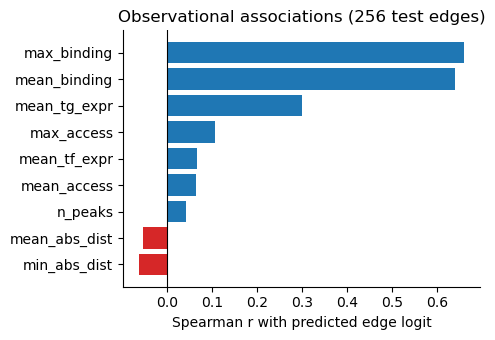

,spearman_r
min_abs_dist,-0.060882
mean_abs_dist,-0.052025
n_peaks,0.042292
mean_access,0.065411
mean_tf_expr,0.066601
max_access,0.106713
mean_tg_expr,0.300668
mean_binding,0.640575
max_binding,0.659683


In [ ]:
# Spearman correlation of each factor with the model's score, on the unperturbed edges.
factors = [
    "n_peaks", "min_abs_dist", "mean_abs_dist", "mean_access", "max_access",
    "mean_binding", "max_binding", "mean_tf_expr", "mean_tg_expr",
]

corr = (
    obs_df[factors + ["pred_logit"]]
    .corr(method="spearman")["pred_logit"]
    .drop("pred_logit")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ["tab:red" if v < 0 else "tab:blue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman r with predicted edge logit")
ax.set_title(f"Observational associations ({len(obs_df)} test edges)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

corr.to_frame("spearman_r")

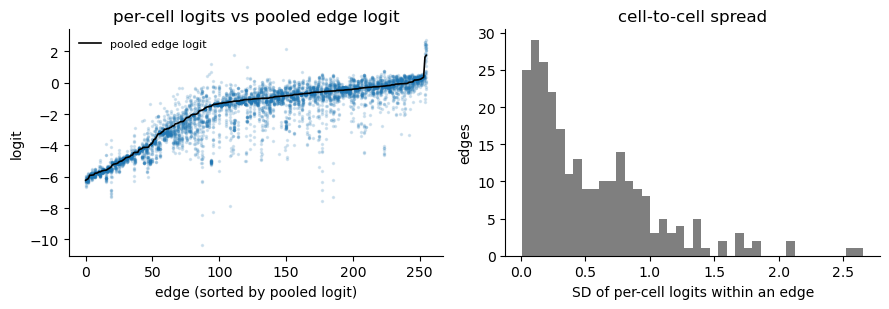

In [ ]:
# The edge score is a log-sum-exp pool over C per-cell logits. How much do cells disagree?
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

order = np.argsort(obs_logits.numpy())
axes[0].plot(obs_cell_logits.numpy()[order], ".", color="tab:blue", alpha=0.15, ms=3)
axes[0].plot(obs_logits.numpy()[order], "-", color="black", lw=1.2, label="pooled edge logit")
axes[0].set_xlabel("edge (sorted by pooled logit)")
axes[0].set_ylabel("logit")
axes[0].set_title("per-cell logits vs pooled edge logit")
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(obs_df["cell_logit_sd"], bins=40, color="tab:grey")
axes[1].set_xlabel("SD of per-cell logits within an edge")
axes[1].set_ylabel("edges")
axes[1].set_title("cell-to-cell spread")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Controlled sweeps

The pattern for every sweep below is the same:

1. Take one fixed batch of real edges.
2. Clone it, overwrite **one** input tensor, run the full forward.
3. Repeat over a grid of values and plot the response.

Everything else — TF identity, peak DNA sequences, the other four factors — is held at its
real value, so the curve is the model's response to that factor alone.

Sweep values are taken from the data's own quantiles wherever possible, so the grids stay
inside the range the model actually saw during training.

In [ ]:
N_SWEEP = 32   # every sweep step is a full forward on this many edges -- keep it small

sweep_batch = collect_edges(loader, n_pos=N_SWEEP // 2, n_neg=N_SWEEP // 2)
sweep_base_prob, sweep_base_logit, _ = predict_edges(sweep_batch)
print("baseline mean prob:", float(sweep_base_prob.mean()))


@torch.no_grad()
def sweep(base_batch, values, apply_fn, desc=""):
    """Run the model once per value, with apply_fn(batch_copy, value) applied in place."""
    rows = []
    for value in tqdm(values, desc=desc):
        perturbed = clone_batch(base_batch)
        apply_fn(perturbed, value)
        probs, logits, _ = predict_edges(perturbed)

        rows.append(pd.DataFrame({
            "value": value,
            "edge": np.arange(len(probs)),
            "tf": base_batch["tf_name"],
            "tg": base_batch["tg_name"],
            "label": base_batch["label"].numpy(),
            "prob": probs.numpy(),
            "logit": logits.numpy(),
        }))

    return pd.concat(rows, ignore_index=True)


def plot_sweep(df, xlabel, title, logx=False, y="prob"):
    fig, ax = plt.subplots(figsize=(5.5, 3.6))

    # Faint line per edge, so you can see whether the mean hides opposite responses.
    for _, edge_df in df.groupby("edge"):
        color = "tab:blue" if edge_df["label"].iloc[0] == 1 else "tab:red"
        ax.plot(edge_df["value"], edge_df[y], color=color, alpha=0.15, lw=0.8)

    for label_value, color, name in [(1, "tab:blue", "true edges"), (0, "tab:red", "false edges")]:
        subset = df[df["label"] == label_value]
        if subset.empty:
            continue
        means = subset.groupby("value")[y].mean()
        ax.plot(means.index, means.values, color=color, lw=2.5, label=name)

    if logx:
        ax.set_xscale("symlog", linthresh=1e3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"predicted edge {y}")
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

collected 16 positives / 16 negatives
baseline mean prob: 0.31608253717422485



### 5a. Number of peaks near the TG

Peaks are cached in order of increasing `|TSS_dist|`, so masking everything past column `k`
means "this TG only has its `k` closest peaks". Masked peaks are dropped from the attention
and their features are zeroed, which is what the model would see for a TG in a peak-poor
region.

The batch is filtered to edges that actually have `MAX_K` real peaks — otherwise the large-`k`
end of the sweep is a mix of edges that changed and edges that were already saturated.

sweeping k = 1..5 on 18 edges with >= 5 real peaks


n peaks:   0%|          | 0/5 [00:00<?, ?it/s]

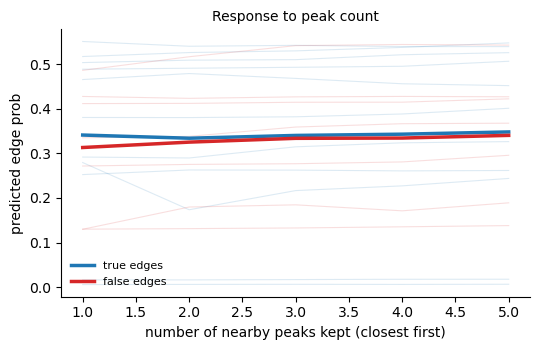

In [ ]:
MAX_K = int(np.percentile(sweep_batch["peak_mask"].sum(1).numpy(), 50))
eligible = torch.nonzero(sweep_batch["peak_mask"].sum(1) >= MAX_K).ravel()
peak_batch = subset_batch(sweep_batch, eligible)
print(f"sweeping k = 1..{MAX_K} on {len(eligible)} edges with >= {MAX_K} real peaks")


def keep_k_closest_peaks(batch, k):
    """Mask out every peak except the k closest to the TSS."""
    P = batch["peak_mask"].shape[1]
    keep = torch.zeros(P, dtype=torch.bool)
    keep[:k] = True
    batch["peak_mask"] = batch["peak_mask"] & keep[None, :]


k_values = sorted(set(np.unique(np.linspace(1, MAX_K, 12).astype(int)).tolist()))
peak_count_df = sweep(peak_batch, k_values, keep_k_closest_peaks, desc="n peaks")

plot_sweep(peak_count_df, "number of nearby peaks kept (closest first)",
           "Response to peak count")


### 5b. Peak-to-TSS distance

Two versions, because they ask different questions:

* **Fixed distance** — every real peak is moved to the same `|TSS_dist| = d`. This isolates
  the distance features: `distance_scaled = clamp(d/250kb, 0, 1)` and
  `distance_weight = exp(-d/50kb)`. The grid deliberately runs past 250 kb to show where the
  clamp flattens the response.
* **Scaled distance** — real distances are multiplied by a factor, preserving each TG's peak
  geometry while pushing the whole neighbourhood in or out.

Note the cache only keeps peaks within 100 kb of the TSS, so distances above that are
extrapolation — informative about the model's function, not about data it was trained on.

fixed distance:   0%|          | 0/12 [00:00<?, ?it/s]

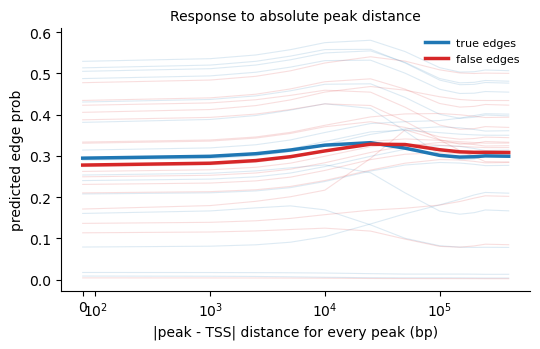

scaled distance:   0%|          | 0/8 [00:00<?, ?it/s]

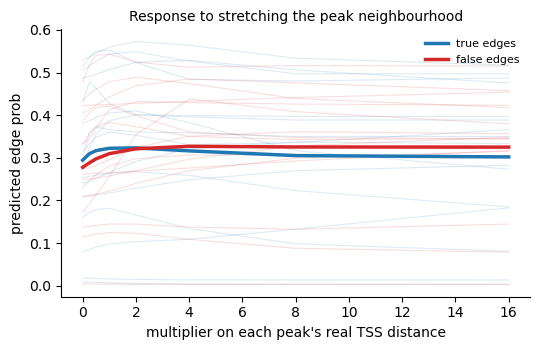

In [ ]:
def set_all_distances(batch, d):
    """Move every real peak to |TSS_dist| = d, keeping its original sign."""
    sign = torch.sign(batch["peak_distance"])
    sign[sign == 0] = 1.0
    batch["peak_distance"] = torch.where(
        batch["peak_mask"], sign * float(d), batch["peak_distance"]
    )


def scale_distances(batch, factor):
    batch["peak_distance"] = torch.where(
        batch["peak_mask"], batch["peak_distance"] * float(factor), batch["peak_distance"]
    )


distance_values = [0, 1e3, 2.5e3, 5e3, 1e4, 2.5e4, 5e4, 1e5, 1.5e5, 2e5, 2.5e5, 4e5]
distance_df = sweep(sweep_batch, distance_values, set_all_distances, desc="fixed distance")
plot_sweep(distance_df, "|peak - TSS| distance for every peak (bp)",
           "Response to absolute peak distance", logx=True)

scale_values = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
distance_scale_df = sweep(sweep_batch, scale_values, scale_distances, desc="scaled distance")
plot_sweep(distance_scale_df, "multiplier on each peak's real TSS distance",
           "Response to stretching the peak neighbourhood")


### 5c. Peak accessibility

`peak_accessibility` is `[E, C, P]`, so setting a constant value replaces the ATAC signal
for every real peak in every sampled cell. The grid is drawn from the observed quantiles of
real-peak accessibility so the values stay on the model's training scale (which depends on
the pseudobulk normalization used for this sample).

observed accessibility quantiles: [0.     0.     0.0095 0.0454 0.101  0.204  0.5343]


accessibility:   0%|          | 0/10 [00:00<?, ?it/s]

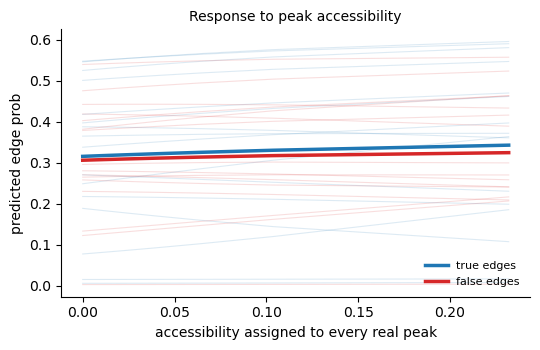

In [ ]:
real_access = obs_batch["peak_accessibility"][obs_batch["peak_mask"][:, None, :].expand_as(obs_batch["peak_accessibility"])]
print("observed accessibility quantiles:",
      np.round(np.quantile(real_access.numpy(), [0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]), 4))


def set_accessibility(batch, a):
    """Set every real peak's accessibility to a, in every sampled cell."""
    full = torch.full_like(batch["peak_accessibility"], float(a))
    batch["peak_accessibility"] = torch.where(
        batch["peak_mask"][:, None, :], full, batch["peak_accessibility"]
    )


# np.unique: ATAC is zero-inflated, so the low quantiles collapse onto 0.0 and would
# otherwise put several sweep points on the same x value.
access_values = np.unique(np.quantile(real_access.numpy(), np.linspace(0.0, 0.995, 12))).tolist()
access_df = sweep(sweep_batch, access_values, set_accessibility, desc="accessibility")

plot_sweep(access_df, "accessibility assigned to every real peak",
           "Response to peak accessibility")


### 5d. TF and TG expression

Expression enters twice: as its own token concatenated into the classifier, and through
`tg_query = tg_query_proj(tf_expr_token + tg_expr_token)`, which is the query that attends
over the peaks. So expression can change the prediction both directly and by re-weighting
which peaks the model looks at.

Both sweeps set a constant value across all `C` sampled cells, which also removes the
cell-to-cell variation the log-sum-exp pooling normally sees.

TF expr quantiles: [0.    0.007 0.133 0.385 1.031 2.964]
TG expr quantiles: [0.    0.003 0.114 0.413 1.018 2.217]


TF expression:   0%|          | 0/11 [00:00<?, ?it/s]

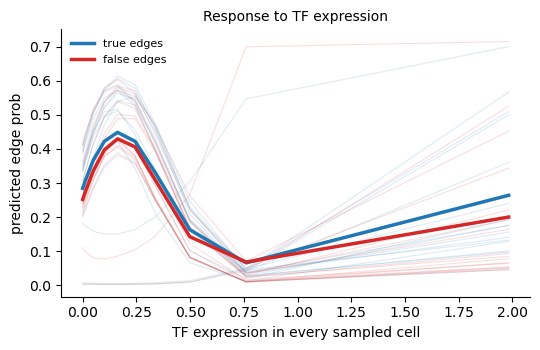

TG expression:   0%|          | 0/10 [00:00<?, ?it/s]

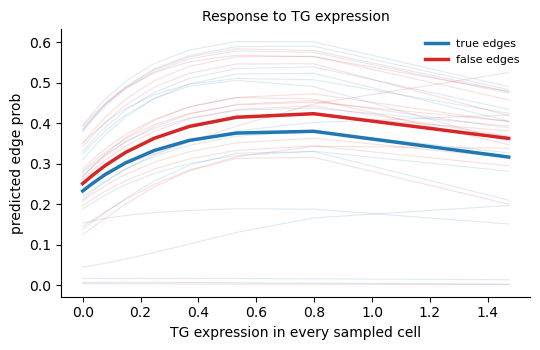

In [ ]:
def set_tf_expression(batch, x):
    batch["tf_expression"] = torch.full_like(batch["tf_expression"], float(x))


def set_tg_expression(batch, x):
    batch["tg_expression"] = torch.full_like(batch["tg_expression"], float(x))


tf_expr_obs = obs_batch["tf_expression"].numpy().ravel()
tg_expr_obs = obs_batch["tg_expression"].numpy().ravel()
print("TF expr quantiles:", np.round(np.quantile(tf_expr_obs, [0, 0.25, 0.5, 0.75, 0.95, 1.0]), 3))
print("TG expr quantiles:", np.round(np.quantile(tg_expr_obs, [0, 0.25, 0.5, 0.75, 0.95, 1.0]), 3))

tf_expr_values = np.unique(np.quantile(tf_expr_obs, np.linspace(0.0, 0.99, 12))).tolist()
tg_expr_values = np.unique(np.quantile(tg_expr_obs, np.linspace(0.0, 0.99, 12))).tolist()

tf_expr_df = sweep(sweep_batch, tf_expr_values, set_tf_expression, desc="TF expression")
plot_sweep(tf_expr_df, "TF expression in every sampled cell", "Response to TF expression")

tg_expr_df = sweep(sweep_batch, tg_expr_values, set_tg_expression, desc="TG expression")
plot_sweep(tg_expr_df, "TG expression in every sampled cell", "Response to TG expression")


### 5e. TF x TG expression interaction

Because the two expression tokens are *summed* before the TG query projection, the model can
only see their joint value through that sum plus the two separate classifier inputs. A 2D
grid shows whether it has learned an interaction (a diagonal ridge) or just an additive
response (parallel contours).

TF x TG grid:   0%|          | 0/6 [00:00<?, ?it/s]

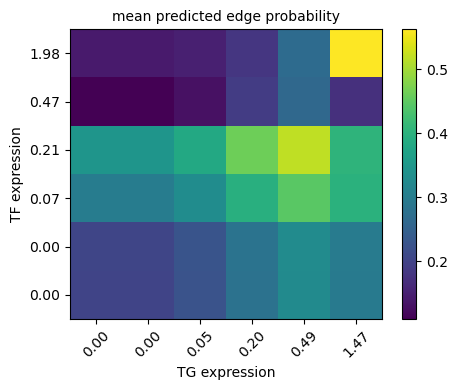

In [ ]:
grid_n = 6
tf_grid = np.unique(np.quantile(tf_expr_obs, np.linspace(0.0, 0.99, grid_n)))
tg_grid = np.unique(np.quantile(tg_expr_obs, np.linspace(0.0, 0.99, grid_n)))

heat = np.zeros((len(tf_grid), len(tg_grid)))
for i, tf_value in enumerate(tqdm(tf_grid, desc="TF x TG grid")):
    for j, tg_value in enumerate(tg_grid):
        perturbed = clone_batch(sweep_batch)
        set_tf_expression(perturbed, tf_value)
        set_tg_expression(perturbed, tg_value)
        probs, _, _ = predict_edges(perturbed)
        heat[i, j] = float(probs.mean())

fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(heat, origin="lower", cmap="viridis", aspect="auto")
ax.set_xticks(range(len(tg_grid)), [f"{v:.2f}" for v in tg_grid], rotation=45)
ax.set_yticks(range(len(tf_grid)), [f"{v:.2f}" for v in tf_grid])
ax.set_xlabel("TG expression")
ax.set_ylabel("TF expression")
ax.set_title("mean predicted edge probability", fontsize=10)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### 5f. TF-DNA binding

Binding is the one peak feature that is *computed*, not looked up, so it cannot be swept by
editing an input tensor without also editing the DNA sequence. Two useful things instead:

* Look at how the binding scores are distributed across peaks, and how the edge score
  relates to them (already in `obs_df` as `mean_binding` / `max_binding`).
* Substitute the DNA: replace each peak's sequence with another peak's, which changes
  binding while leaving distance, accessibility, and expression untouched. That isolates the
  TF-DNA contribution to the TF-TG head.

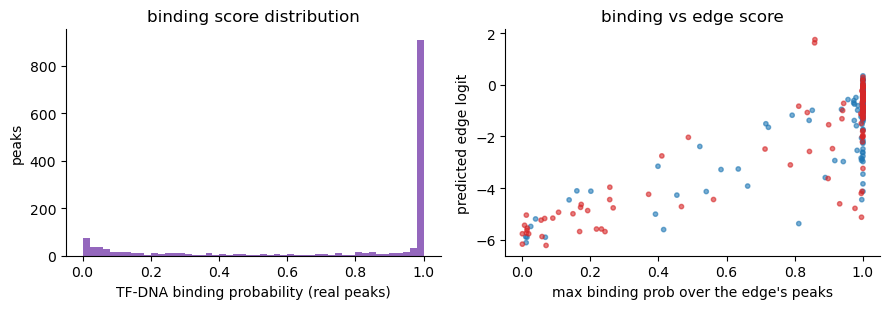

In [ ]:
# How much of the binding signal is TF-specific vs peak-specific?
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

real_binding = obs_binding[mask].numpy()
axes[0].hist(real_binding, bins=50, color="tab:purple")
axes[0].set_xlabel("TF-DNA binding probability (real peaks)")
axes[0].set_ylabel("peaks")
axes[0].set_title("binding score distribution")

axes[1].scatter(obs_df["max_binding"], obs_df["pred_logit"],
                c=np.where(obs_df["label"] == 1, "tab:blue", "tab:red"), s=10, alpha=0.6)
axes[1].set_xlabel("max binding prob over the edge's peaks")
axes[1].set_ylabel("predicted edge logit")
axes[1].set_title("binding vs edge score")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

DNA shuffle:   0%|          | 0/6 [00:00<?, ?it/s]

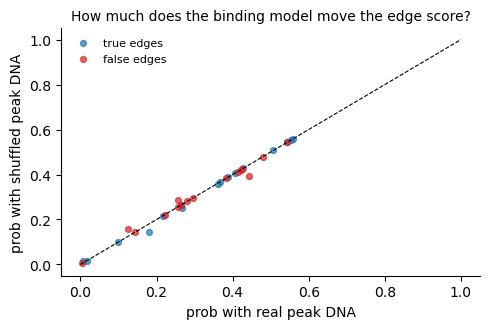

In [ ]:
# Shuffle which DNA sequence each peak carries, across edges in the batch. Distances,
# accessibility, and expression stay exactly where they were -- only binding changes.
def shuffle_peak_dna(batch, seed):
    generator = torch.Generator().manual_seed(int(seed))
    E = batch["peak_sequences"].shape[0]
    perm = torch.randperm(E, generator=generator)
    batch["peak_sequences"] = batch["peak_sequences"][perm]


shuffle_df = sweep(sweep_batch, list(range(6)), shuffle_peak_dna, desc="DNA shuffle")

fig, ax = plt.subplots(figsize=(5, 3.4))
for label_value, color, name in [(1, "tab:blue", "true edges"), (0, "tab:red", "false edges")]:
    real = sweep_base_prob.numpy()[sweep_batch["label"].numpy() == label_value]
    shuffled = shuffle_df[shuffle_df["label"] == label_value].groupby("edge")["prob"].mean().values
    ax.scatter(real, shuffled, color=color, s=18, alpha=0.7, label=name)

lims = [0, 1]
ax.plot(lims, lims, color="black", lw=0.8, ls="--")
ax.set_xlabel("prob with real peak DNA")
ax.set_ylabel("prob with shuffled peak DNA")
ax.set_title("How much does the binding model move the edge score?", fontsize=10)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Where to take this next

Cheap extensions on top of the harness above:

* **Per-TF or per-TG response curves.** `sweep()` keeps `tf` / `tg` columns, so
  `df.groupby("tf")` gives one curve per TF — useful for asking whether the model has
  learned TF-specific distance preferences or just one global shape.
* **Compare against the ablations.** `models/simplified_models/` has `no_binding`,
  `no_expr_info`, `no_peak_info`, `no_peak_tg_distance` variants trained by
  `test_simplified_model_multigpu_safe.py`. Load one the same way and re-run a sweep to see
  which factor the full model is actually using.
* **Attention weights.** `TFTGRegulationModel.forward` calls `self.peak_attention` with
  `need_weights=False`. Flip it to `True` in a local copy to get the `[E*C, 1, P]` weights and
  see which peak the TG query is attending to as you move a factor.
* **Pooling.** `predict_edges` uses the checkpoint's pooling (`lse` at
  `pooling_temperature`). `TFTGRegulationModel.pool_cell_logits` also supports `mean` and
  `max`; re-pooling the cached `cell_logits` shows how much the edge score depends on that
  choice.
* **Cross-sample.** Change `config.sample_name` (or pass a different `SAMPLE_NAME` /
  checkpoint in §0-§2) to check whether the response curves are a property of the model or of
  the dataset.